In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO


pep_hits_long = pd.read_csv('long_091826.csv')

In [2]:
lassa = pep_hits_long[pep_hits_long['species'] == 'Mammarenavirus lassaense'].copy()

## importing the reference sequences fetched from UniProt (UP000002473_11622.fasta)

In [3]:
records = list(SeqIO.parse('UP000002473_11622_LASV_Josiah_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|O09705|L_LASSJ 2218
sp|O73557|Z_LASSJ 99
sp|P08669|GLYC_LASSJ 491
sp|P13699|NCAP_LASSJ 569


In [4]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "O09705" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "P08669" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P13699" in r.id)),
    "z protein": str(next(r.seq for r in records if "O73557" in r.id)),
}

In [5]:
print(lassa['category'].value_counts())
print(lassa['sequence'].nunique())
print(lassa['protein_std'].unique())

category
Household contact    21052
Lassa survivor        9120
US healthy            6612
Name: count, dtype: int64
76
['polymerase' 'glycoprotein' 'nucleoprotein' 'z protein']


## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [6]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## polymerase

In [7]:
ref = reference_by_protein['polymerase']

np = lassa[lassa['protein_std'].eq("polymerase")].copy()

unique_np_peptides = np['sequence'].drop_duplicates()

In [8]:
ref

'MEEDIACVKDLVSKYLVDNERLSRQKLAFLVQTEPRMLLMEGLKLLSLCIEVDSCNANGCEHNSEDKSVERILHDHGILTPSLCLWYPDGYKLTGNVLILLECFVRSSPANFEQKYIEDFKKLEQLKEDLKSVDINLIPLIDGRTSFYNEQIPDWVNDKLRDTLFSLLKYAQESNSLFEESEYSRLCESLFMTSGRLSGVESLNVLMDNRSNHYEEVIASCHQGINNKLTAHEVKLQIEEEYQVFRNRLRKGEIEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILRFLYANVDEGNEKRGNQTIGECQVQCWRSFLNKVKSLRILNTRRKLLLIFDALILLASKHDLMKQKCLKGWLGSCFLRVKDRLVSLEATKRDLEKWGERGNRLRSRITQSSQCLSKNQILNSIFQKTILKATTALKDVGISVDHYKIDMEVICLNSYDLIMDFDVSGVVPTISYQRTEEETFPYVMGDVELLGTTDLERLSSLSLALVNSMKTSSTVKLRQNEFGPARYQVVRCKEAYCQEFSLGNTELQLIYQKTGECSKCYAINDNKVGEVCSFYADPKRYFPAIFSAEVLQTTISTMISWIEDCNELEGQLNNIRSLTKMILVLILAHPSKRSQKLLQNLRYFVMAYLSDYHHKDLIDKIREELITDVEFLLYRLIRTLMNLVLSEDVKSMMTNRFKFILNVSYMCHFITKETPDRLTDQIKCFEKFLEPKVRFGHVSTNPADTATEEELDDMVYNAKKFLSKDGCTTIEGPDYKRPGVSKKYLSLLTSSFNNGSLFKEREVKREIKDPLITSGSAALDLASKKSVVVNKYTDGSRILNYDFNKLTALAVSQLTEVFSRKGKYLLNKQDYEYKVQQAMSNLVLGSGQLKSDADGADLDEILLDGGASDYFDQLKETVEKIVDQYREPVKLGSGPNGDGQPSINDLDEIVSNKFYIRLIKGELSNHMVEEFDHDILPGKFYEEFCNAVYENSRLKQKYF

## define mapping function -> adjusted for polymerase peptides being mapped as full 46aa- peptides, rather than e.g. 36 aa peptides. first infer position with local alignment, then derive the entire position of the peptide to the ref sequence

In [9]:
def map_peptide_to_reference(peptide, reference, aligner):

    alignment = aligner.align(reference, peptide)[0]

    ref_blocks, peptide_blocks = alignment.aligned

    # Local alignment coordinates
    aligned_ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(
        ref_blocks, peptide_blocks
    ):
        for i in range(ref_end - ref_start):
            aligned_ref_positions.append(ref_start + i + 1)

    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1]

    aligned_length = sum(
        end - start for start, end in peptide_blocks
    )

    # Infer where the complete peptide begins on the reference
    full_ref_start = aligned_ref_positions[0] - (pep_start - 1)
    full_ref_end = full_ref_start + len(peptide) - 1

    full_ref_positions = list(
        range(full_ref_start, full_ref_end + 1)
    )

    return {
        "score": alignment.score,

        # local alignment
        "aligned_ref_start": aligned_ref_positions[0],
        "aligned_ref_end": aligned_ref_positions[-1],
        "aligned_ref_positions": aligned_ref_positions,
        "pep_start": pep_start,
        "pep_end": pep_end,
        "aligned_length": aligned_length,
        "fraction_aligned": aligned_length / len(peptide),

        # inferred complete peptide location
        "ref_start": full_ref_start,
        "ref_end": full_ref_end,
        "ref_positions": full_ref_positions
    }

In [10]:
mapping = []

for peptide in unique_np_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length']

    })

np_mapping = pd.DataFrame(mapping)

In [11]:
np_mapping['aligned_pep_length'].describe()

count    62.000000
mean     45.209677
std       2.112702
min      36.000000
25%      45.250000
50%      46.000000
75%      46.000000
max      46.000000
Name: aligned_pep_length, dtype: float64

In [12]:
#check the length of peptide alignment, should be 46 now that we chose a different mapping approach
np_mapping['alignment_length'] = np_mapping['ref_positions'].str.len()
np_mapping['alignment_length'].describe()

count    62.0
mean     46.0
std       0.0
min      46.0
25%      46.0
50%      46.0
75%      46.0
max      46.0
Name: alignment_length, dtype: float64

In [32]:
np_mapping.shape

(62, 9)

In [38]:
np_mapping.sort_values('ref_start')[['ref_start', 'ref_end']].drop_duplicates().head(50)

,ref_start,ref_end
39,47,92
3,185,230
44,208,253
20,227,272
48,231,276
38,254,299
0,274,319
12,276,321
36,439,484
21,458,503


In [14]:
np_mapping.sort_values('aligned_pep_length').head(50)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
50,KVDVCDDDVEHLEFQFKRASPVLKFLYANLDPSGDKTVNPQGEQMQ,120.0,276,321,"[276, 277, 278, 279, 280, 281, 282, 283, 284, ...",4,39,36,46
32,LDEVLLDGGASMYFDQLRETVEKIVDQYKEPLRQNSHSITGDRASI,148.0,898,943,"[898, 899, 900, 901, 902, 903, 904, 905, 906, ...",1,36,36,46
45,KADLDEVLLEGDANIYFDQLRETIEKIVDQYREPTKSNSSFKDSSQ,148.0,895,940,"[895, 896, 897, 898, 899, 900, 901, 902, 903, ...",2,39,38,46
12,EGIADEDSIEQLCYQFKRASPILRFLYADLENRGPKGPAVDGCQMQ,117.0,276,321,"[276, 277, 278, 279, 280, 281, 282, 283, 284, ...",3,46,42,46
6,EYFDQLRCTVDNIVSQYREQPERQQQTGCNAPSISDLDKVVEEKLL,99.5,909,954,"[909, 910, 911, 912, 913, 914, 915, 916, 917, ...",1,44,43,46
0,TDDAVVAEDDIEQLIYQFKRASPILRFLYSDIEGEEDRKNVQVVKE,139.0,274,319,"[274, 275, 276, 277, 278, 279, 280, 281, 282, ...",3,46,43,46
35,SISDLDKVVEEKLSIRLIKSELSNHMVEDFDREILSEDQYIKICEG,130.0,942,987,"[942, 943, 944, 945, 946, 947, 948, 949, 950, ...",1,44,44,46
4,SFDVSGVIPTITYQRSEEEKFPYVTGDVELLRTTDLERLSSLSLAL,194.0,460,505,"[460, 461, 462, 463, 464, 465, 466, 467, 468, ...",2,46,45,46
20,NKLSAHEVKTQIEEEYQVFRNRIRQGEIECQFIRVDQEELMREFNG,173.0,227,272,"[227, 228, 229, 230, 231, 232, 233, 234, 235, ...",1,45,45,46
34,QLGDVIPMKLIISPDKLQFSEFDFTKVGPDNEPVPLVVCRGALWES,143.0,2047,2092,"[2047, 2048, 2049, 2050, 2051, 2052, 2053, 205...",1,45,45,46


In [15]:
#inspect the shortest mappings: 
np_mapping.sort_values("alignment_length").head(50)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,TDDAVVAEDDIEQLIYQFKRASPILRFLYSDIEGEEDRKNVQVVKE,139.0,274,319,"[274, 275, 276, 277, 278, 279, 280, 281, 282, ...",3,46,43,46
1,RESTSRSITEDFFYSNYQNGVVPSHISSVLDMGQGILHNTSDFYAL,209.0,1261,1306,"[1261, 1262, 1263, 1264, 1265, 1266, 1267, 126...",1,46,46,46
2,LRQKVIYSGAVNLDDDKIPTIVKTIQNKLSSTFTRGAQKLLSEAIN,218.0,1560,1605,"[1560, 1561, 1562, 1563, 1564, 1565, 1566, 156...",1,46,46,46
3,RLCESLSMTSGRLSGVESLNVLLDNRSNHYEEVITSCHQGINNKLT,223.0,185,230,"[185, 186, 187, 188, 189, 190, 191, 192, 193, ...",1,46,46,46
4,SFDVSGVIPTITYQRSEEEKFPYVTGDVELLRTTDLERLSSLSLAL,194.0,460,505,"[460, 461, 462, 463, 464, 465, 466, 467, 468, ...",2,46,45,46
5,DFDVSGVTPTISYQRSEEGTFPYTMGDVDLLGTTDLERLSSVSLAL,203.0,460,505,"[460, 461, 462, 463, 464, 465, 466, 467, 468, ...",1,46,46,46
6,EYFDQLRCTVDNIVSQYREQPERQQQTGCNAPSISDLDKVVEEKLL,99.5,909,954,"[909, 910, 911, 912, 913, 914, 915, 916, 917, ...",1,44,43,46
7,SFVATTRTLGSFTWFPHKTSIPEGEGLQRLGPFSSFIEKAIYKGIE,219.0,1855,1900,"[1855, 1856, 1857, 1858, 1859, 1860, 1861, 186...",2,46,45,46
8,LTNSSGVQYWRVPLSIRSGNEAVTSYFRPLLWDYMCISLSTAIELG,203.5,1655,1700,"[1655, 1656, 1657, 1658, 1659, 1660, 1661, 166...",1,46,46,46
9,NAKKFLSKGTCVDSNKIEYKCPGISRKYLSLLTSSFNNGSLFKGKE,159.0,757,802,"[757, 758, 759, 760, 761, 762, 763, 764, 765, ...",1,46,46,46


## inspecting alignments which are shorter than expected (36-38 aa instead of >40aa)

In [16]:
short = np_mapping.sort_values("alignment_length").head(3)

for _, row in short.iterrows():
    peptide = row["sequence"]

    alignment = aligner.align(ref, peptide)[0]

    print("\n" + "=" * 80)
    print(peptide)
    print(alignment)


TDDAVVAEDDIEQLIYQFKRASPILRFLYSDIEGEEDRKNVQVVKE
target          275 DKVVAEDNIEHLIYQFKRASPILRFLYANVDEGNEKRGN-QTIGE 319
                  0 |.|||||.||.||||||||||||||||...-||.|.|.|-|...|  45
query             2 DAVVAEDDIEQLIYQFKRASPILRFLYSDI-EGEEDRKNVQVVKE  46


RESTSRSITEDFFYSNYQNGVVPSHISSVLDMGQGILHNTSDFYAL
target         1260 RKKTKQSITEDFFYSNFQAGVVPSHISSILDMGQGILHNTSDFYAL 1306
                  0 |..|..||||||||||.|.|||||||||.|||||||||||||||||   46
query             0 RESTSRSITEDFFYSNYQNGVVPSHISSVLDMGQGILHNTSDFYAL   46


LRQKVIYSGAVNLDDDKIPTIVKTIQNKLSSTFTRGAQKLLSEAIN
target         1559 LRQKIIYSGAVNLDDEKIPTIVKTIQNKLSSTFTRGAQKLLSEAIN 1605
                  0 ||||.||||||||||.||||||||||||||||||||||||||||||   46
query             0 LRQKVIYSGAVNLDDDKIPTIVKTIQNKLSSTFTRGAQKLLSEAIN   46



## merging the mapping back to the individual-level dataframe


In [17]:
np = np.merge(np_mapping, on='sequence', how='left')

In [18]:
np.shape

(30008, 21)

## .explode() turns one peptide/individual row to one row per amino-acid position covered by that peptide

In [19]:
np_residues = np.explode('ref_positions').rename(columns={'ref_positions': 'position'})

## keep only reactive peptides

In [20]:
reactive_residues = np_residues[np_residues['reactive']].copy()

## now we have the people and amino acid positions at which they have nucleoprotein antibody reactivity. But we need to remove contributions to the same amino-acid position. each individual can contribute at most one to a given amino acid position. 

In [21]:
reactive_residues = reactive_residues[['individual', 'cohort', 'category', 'position']].drop_duplicates()

In [22]:
reactive_residues['individual'].unique() #no US healthies, as expected

array(['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-135-2_1_D2',
       'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3',
       'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4',
       'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5',
       'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4',
       'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2',
       'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5',
       'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7',
       'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1',
       'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6',
       'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-3_1_E4',
       'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4',
       'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8',
       'C-467-1_2_D6', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5',
      

## calculate number of individuals in each category

In [23]:
group_sizes = (
    np[['individual', 'cohort', 'category']].drop_duplicates().groupby(['cohort', 'category']).size().rename('n_individuals').reset_index()
)

group_sizes

,cohort,category,n_individuals
0,HBDB,US healthy,87
1,SL,Household contact,277
2,SL,Lassa survivor,120


## now count reactive individuals at each position

In [24]:
position_counts = (
    reactive_residues.groupby(['cohort', 'category', 'position'])['individual'] #reactive residues only include SL individuals
    .nunique()
    .rename('n_seroreactive')
    .reset_index()
)

position_counts.head(2)

,cohort,category,position,n_seroreactive
0,SL,Household contact,47,17
1,SL,Household contact,48,17


In [25]:
position_summary = position_counts.merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary.head(2)

,cohort,category,position,n_seroreactive,n_individuals
0,SL,Household contact,47,17,277
1,SL,Household contact,48,17,277


In [26]:
position_summary['pct_seroreactive'] = (
    position_summary['n_seroreactive'] / position_summary['n_individuals'] * 100
)

In [27]:
position_summary.head(3)

,cohort,category,position,n_seroreactive,n_individuals,pct_seroreactive
0,SL,Household contact,47,17,277,6.137184
1,SL,Household contact,48,17,277,6.137184
2,SL,Household contact,49,17,277,6.137184


## add positions with zero seroreactivity 

In [28]:
all_positions = pd.DataFrame({'position': range(1, len(ref) + 1)}) #initiate a dataframe with one column

groups = np[['cohort', 'category']].drop_duplicates()

complete_grid = groups.merge(all_positions, how='cross')

complete_grid.head(2)

,cohort,category,position
0,SL,Household contact,1
1,SL,Household contact,2


In [29]:
position_summary = complete_grid.merge(
    position_summary,
    on=["cohort", "category", "position"],
    how="left"
)

position_summary["n_seroreactive"] = (
    position_summary["n_seroreactive"]
    .fillna(0)
)

position_summary = position_summary.drop(columns='n_individuals').merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary['pct_seroreactive'] = 100 * position_summary['n_seroreactive'] / position_summary['n_individuals']

In [30]:
position_summary

,cohort,category,position,n_seroreactive,pct_seroreactive,n_individuals
0,SL,Household contact,1,0.0,0.0,277
1,SL,Household contact,2,0.0,0.0,277
2,SL,Household contact,3,0.0,0.0,277
3,SL,Household contact,4,0.0,0.0,277
4,SL,Household contact,5,0.0,0.0,277
...,...,...,...,...,...,...
6649,HBDB,US healthy,2214,0.0,0.0,87
6650,HBDB,US healthy,2215,0.0,0.0,87
6651,HBDB,US healthy,2216,0.0,0.0,87
6652,HBDB,US healthy,2217,0.0,0.0,87


## Now going to plot the % of cohort/ category reactive to the amino acid positions of the nucleoprotein

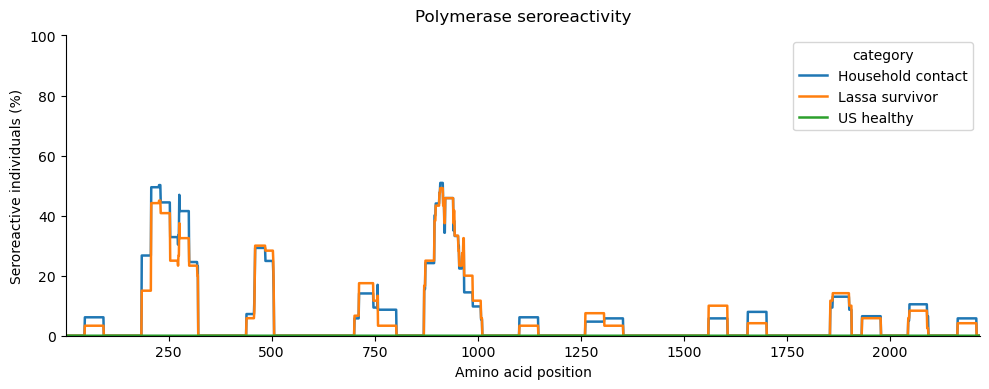

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position')
ax.set_ylabel('Seroreactive individuals (%)')
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('Polymerase seroreactivity', y=1.02)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('polymerase_reactivity.svg', format='svg')
plt.show()